In [63]:
# ============================================================
# CELL 1: Import & Load Session
# ============================================================
import numpy as np
import pickle
import random
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score,
                            confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load session
with open('session/session_preprocessing.pkl', 'rb') as f:
    sv = pickle.load(f)

le               = sv['le']
scaler           = sv['scaler']
num_classes      = sv['num_classes']
SEED             = sv['SEED']
ecocrop_gaussian = sv['ecocrop_gaussian']
physics_features = sv['physics_features']

X_train          = sv['X_train']
X_val            = sv['X_val']
X_test           = sv['X_test']
X_train_scaled   = sv['X_train_scaled']
X_val_scaled     = sv['X_val_scaled']
X_test_scaled    = sv['X_test_scaled']
y_train_oh       = sv['y_train_oh']
y_val_oh         = sv['y_val_oh']
y_test_oh        = sv['y_test_oh']
y_test           = sv['y_test']

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print("✅ Session loaded")
print(f"   Physics features : {physics_features}")
print(f"   SEED             : {SEED}")

✅ Session loaded
   Physics features : ['temperature', 'ph']
   SEED             : 42


In [64]:
# ============================================================
# CELL 2: Konfigurasi
# ============================================================

# Arsitektur (sama dengan baseline)
INPUT_DIM      = 7
HIDDEN_DIM     = 32
OUTPUT_DIM     = num_classes  # 22

# Training
EPOCHS         = 100
BATCH_SIZE     = 32
LR             = 0.001
LAMBDA_PHYSICS = 1.0

# Index fitur di X (sebelum scaling)
TEMP_IDX = 3  # temperature
PH_IDX   = 5  # ph

print("✅ Konfigurasi:")
print(f"   Arsitektur     : {INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}")
print(f"   Epochs         : {EPOCHS}")
print(f"   Batch size     : {BATCH_SIZE}")
print(f"   LR             : {LR}")
print(f"   λ_physics      : {LAMBDA_PHYSICS}")
print(f"   Physics params : temperature (idx {TEMP_IDX}), "
      f"pH (idx {PH_IDX})")

✅ Konfigurasi:
   Arsitektur     : 7→32→22
   Epochs         : 100
   Batch size     : 32
   LR             : 0.001
   λ_physics      : 1.0
   Physics params : temperature (idx 3), pH (idx 5)


In [65]:
# ============================================================
# CELL 3: Bangun Physics Constraint Tensors
# Rujukan: BAB 3 hal 40-42
#
# μ dan σ di-scale agar konsisten dengan
# input model yang sudah di-StandardScaler
# ============================================================

crop_names   = list(le.classes_)
scaler_mean  = scaler.mean_
scaler_std   = scaler.scale_

# Hitung μ dan σ dari ECOCROP gaussian
physics_mu    = np.zeros((22, 2))  # (22 tanaman, 2 fitur)
physics_sigma = np.zeros((22, 2))

for i, crop in enumerate(crop_names):
    physics_mu[i, 0]    = ecocrop_gaussian[crop]['temperature'][0]
    physics_mu[i, 1]    = ecocrop_gaussian[crop]['ph'][0]
    physics_sigma[i, 0] = ecocrop_gaussian[crop]['temperature'][1]
    physics_sigma[i, 1] = ecocrop_gaussian[crop]['ph'][1]

# Scale μ dan σ
feat_indices         = [TEMP_IDX, PH_IDX]
physics_mu_scaled    = (physics_mu - scaler_mean[feat_indices]) \
                        / scaler_std[feat_indices]
physics_sigma_scaled = physics_sigma / scaler_std[feat_indices]

# Konversi ke TF constant
physics_mu_tf    = tf.constant(physics_mu_scaled,    dtype=tf.float32)
physics_sigma_tf = tf.constant(physics_sigma_scaled, dtype=tf.float32)

# Verifikasi Rice
rice_idx = crop_names.index('rice')
print("✅ Physics constraint tensors siap")
print(f"\nVerifikasi Rice (index {rice_idx}):")
print(f"  Temp original : μ={physics_mu[rice_idx,0]:.3f}, "
      f"σ={physics_sigma[rice_idx,0]:.3f}")
print(f"  Temp scaled   : μ={physics_mu_scaled[rice_idx,0]:.4f}, "
      f"σ={physics_sigma_scaled[rice_idx,0]:.4f}")
print(f"  pH original   : μ={physics_mu[rice_idx,1]:.3f}, "
      f"σ={physics_sigma[rice_idx,1]:.3f}")
print(f"  pH scaled     : μ={physics_mu_scaled[rice_idx,1]:.4f}, "
      f"σ={physics_sigma_scaled[rice_idx,1]:.4f}")

✅ Physics constraint tensors siap

Verifikasi Rice (index 20):
  Temp original : μ=25.000, σ=1.667
  Temp scaled   : μ=-0.1138, σ=0.3253
  pH original   : μ=6.250, σ=0.250
  pH scaled     : μ=-0.2833, σ=0.3222


In [66]:
# ============================================================
# CELL 4: Loss Functions
# Rujukan: BAB 3 hal 49-52
# ============================================================

# ------------------------------------------------------------
# Data Loss — Categorical Cross-Entropy
# L_data = -1/N Σ Σ y_ic × log(ŷ_ic)
# ------------------------------------------------------------
def data_loss_fn(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    return -tf.reduce_mean(
        tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1)
    )

# ------------------------------------------------------------
# Physics Loss
# Rujukan: BAB 3 hal 50-52
#
# temp_score = exp(-(T_input - μ_T,c)² / 2σ²_T,c)
# pH_score   = exp(-(pH_input - μ_pH,c)² / 2σ²_pH,c)
# env_score  = temp_score × pH_score
# L_physics  = (1 - crop_prob_gt) × env_score_gt
#
# crop_prob dan env_score diambil untuk
# kelas GROUND TRUTH saja
# ------------------------------------------------------------
def physics_loss_fn(X_batch_scaled, y_pred, y_true_oh):
    # Ambil fitur lingkungan (sudah scaled)
    temp = X_batch_scaled[:, TEMP_IDX:TEMP_IDX+1]  # (batch, 1)
    ph   = X_batch_scaled[:, PH_IDX:PH_IDX+1]      # (batch, 1)

    # μ dan σ untuk semua 22 kelas (sudah scaled)
    mu_t  = physics_mu_tf[:, 0]     # (22,)
    mu_p  = physics_mu_tf[:, 1]     # (22,)
    sig_t = physics_sigma_tf[:, 0]  # (22,)
    sig_p = physics_sigma_tf[:, 1]  # (22,)

    # Gaussian score untuk semua kelas (batch, 22)
    temp_score = tf.exp(
        -tf.square(temp - mu_t) / (2 * tf.square(sig_t))
    )
    ph_score   = tf.exp(
        -tf.square(ph - mu_p) / (2 * tf.square(sig_p))
    )

    # env_score = temp × pH (batch, 22)
    env_score = temp_score * ph_score

    # Ambil untuk kelas GROUND TRUTH saja
    # y_true_oh adalah one-hot → multiply + sum = ambil GT
    env_score_gt  = tf.reduce_sum(
        y_true_oh * env_score, axis=1
    )  # (batch,)
    crop_prob_gt  = tf.reduce_sum(
        y_true_oh * y_pred, axis=1
    )  # (batch,)

    # Physics loss: selalu [0, 1]
    # Gunasekaran
    # physics_loss  = tf.reduce_mean((1 - crop_prob_gt) * env_score_gt)
    # rumus +
    # komponen_underconfidence = (1.0 - crop_prob_gt) * env_score_gt
    # komponen_overconfidence = crop_prob_gt * (1.0 - env_score_gt)
    # physics_loss  = tf.reduce_mean(komponen_underconfidence + komponen_overconfidence)
    # Menggunakan tf.maximum sesuai proposal Anda
    komponen_1 = (1.0 - crop_prob_gt) * env_score_gt
    komponen_2 = crop_prob_gt * (1.0 - env_score_gt)
    physics_loss = tf.reduce_mean(tf.maximum(komponen_1, komponen_2))

    return physics_loss, env_score_gt, crop_prob_gt

# Test kedua loss
X_dummy    = tf.constant(X_train_scaled[:32], dtype=tf.float32)
y_oh_dummy = tf.constant(y_train_oh[:32],     dtype=tf.float32)

tf.random.set_seed(SEED)
test_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(HIDDEN_DIM, activation='relu'),
    tf.keras.layers.Dense(OUTPUT_DIM, activation='softmax')
])
y_pred_dummy = test_model(X_dummy, training=False)

dl           = data_loss_fn(y_oh_dummy, y_pred_dummy)
pl, env, cp  = physics_loss_fn(X_dummy, y_pred_dummy, y_oh_dummy)

print("✅ Loss functions siap")
print(f"   Data loss    : {dl.numpy():.4f} "
      f"(ekspektasi ~{np.log(OUTPUT_DIM):.4f})")
print(f"   Physics loss : {pl.numpy():.4f} "
      f"(harus 0-1, tidak negatif)")
print(f"   Avg env_score: {tf.reduce_mean(env).numpy():.4f}")
print(f"   Avg crop_prob: {tf.reduce_mean(cp).numpy():.4f} "
      f"(ekspektasi ~{1/OUTPUT_DIM:.4f})")

assert pl.numpy() >= 0, "❌ Physics loss negatif!"
assert pl.numpy() <= 1, "❌ Physics loss > 1!"
print("\n✅ Physics loss valid (antara 0 dan 1)")

✅ Loss functions siap
   Data loss    : 3.2253 (ekspektasi ~3.0910)
   Physics loss : 0.1333 (harus 0-1, tidak negatif)
   Avg env_score: 0.1116
   Avg crop_prob: 0.0431 (ekspektasi ~0.0455)

✅ Physics loss valid (antara 0 dan 1)


In [67]:
# ============================================================
# CELL 5: Training Loop Fixed-PINN
# Rujukan: BAB 3 hal 52
#
# L_total = L_data + λ × L_physics
# ============================================================

def train_epoch_pinn(model, optimizer, X_scaled, X_orig,
                     y_oh, batch_size, seed_offset):
    """
    Satu epoch training Fixed-PINN
    X_scaled : input untuk model (sudah StandardScaler)
    X_orig   : input original (untuk physics loss)
    """
    n = X_scaled.shape[0]
    np.random.seed(SEED + seed_offset)
    idx      = np.random.permutation(n)
    X_scaled = X_scaled[idx]
    X_orig   = X_orig[idx]
    y_oh     = y_oh[idx]

    total_losses   = []
    data_losses    = []
    physics_losses = []
    correct        = 0

    for i in range(0, n, batch_size):
        X_s = tf.constant(X_scaled[i:i+batch_size], dtype=tf.float32)
        X_o = tf.constant(X_orig[i:i+batch_size],   dtype=tf.float32)
        y_b = tf.constant(y_oh[i:i+batch_size],     dtype=tf.float32)

        with tf.GradientTape() as tape:
            y_pred    = model(X_s, training=True)
            l_data    = data_loss_fn(y_b, y_pred)
            l_physics, _, _ = physics_loss_fn(X_s, y_pred, y_b)
            loss      = l_data + LAMBDA_PHYSICS * l_physics

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(
            zip(grads, model.trainable_variables)
        )

        total_losses.append(loss.numpy())
        data_losses.append(l_data.numpy())
        physics_losses.append(l_physics.numpy())
        correct += np.sum(
            np.argmax(y_pred.numpy(), axis=1) ==
            np.argmax(y_b.numpy(), axis=1)
        )

    return (np.mean(total_losses),
            np.mean(data_losses),
            np.mean(physics_losses),
            correct / n)


def evaluate_pinn(model, X_scaled, X_orig, y_oh):
    """Evaluasi Fixed-PINN"""
    X_s    = tf.constant(X_scaled, dtype=tf.float32)
    X_o    = tf.constant(X_orig,   dtype=tf.float32)
    y_tf   = tf.constant(y_oh,     dtype=tf.float32)
    y_pred = model(X_s, training=False)

    l_data          = data_loss_fn(y_tf, y_pred).numpy()
    l_physics, _, _ = physics_loss_fn(X_s, y_pred, y_tf)
    l_physics       = l_physics.numpy()
    total_loss      = l_data + LAMBDA_PHYSICS * l_physics

    acc = np.mean(
        np.argmax(y_pred.numpy(), axis=1) ==
        np.argmax(y_oh, axis=1)
    )
    return total_loss, l_data, l_physics, acc


print("✅ Training loop siap")

✅ Training loop siap


In [68]:
# ============================================================
# CELL 6: Training Fixed-PINN
# ============================================================
tf.random.set_seed(SEED)
model_pinn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(HIDDEN_DIM, activation='relu'),
    tf.keras.layers.Dense(OUTPUT_DIM, activation='softmax')
])

optimizer_pinn = tf.keras.optimizers.Adam(learning_rate=LR)

history = {
    'train_total'  : [], 'val_total'   : [],
    'train_data'   : [], 'val_data'    : [],
    'train_physics': [], 'val_physics' : [],
    'train_acc'    : [], 'val_acc'     : []
}

print(f"=== TRAINING FIXED-PINN (λ={LAMBDA_PHYSICS}) ===")
print(f"Arsitektur : {INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}")
print(f"Epochs     : {EPOCHS}\n")

for epoch in range(EPOCHS):
    # Training
    tr_total, tr_data, tr_physics, tr_acc = train_epoch_pinn(
        model_pinn, optimizer_pinn,
        X_train_scaled, X_train,
        y_train_oh, BATCH_SIZE, seed_offset=epoch
    )

    # Validasi
    vl_total, vl_data, vl_physics, vl_acc = evaluate_pinn(
        model_pinn,
        X_val_scaled, X_val, y_val_oh
    )

    history['train_total'].append(tr_total)
    history['val_total'].append(vl_total)
    history['train_data'].append(tr_data)
    history['val_data'].append(vl_data)
    history['train_physics'].append(tr_physics)
    history['val_physics'].append(vl_physics)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    
    # ── Cetak epoch 1 secara eksplisit ──
    if epoch == 0:
        print(f"Epoch   1/{EPOCHS} | "
              f"total: {tr_total:.4f} | "
              f"data: {tr_data:.4f} | "
              f"physics: {tr_physics:.4f} | "
              f"val_acc: {vl_acc:.4f}")

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"total: {tr_total:.4f} | "
              f"data: {tr_data:.4f} | "
              f"physics: {tr_physics:.4f} | "
              f"val_acc: {vl_acc:.4f}")

print(f"\n✅ Training selesai")
print(f"   Best Val Acc  : {max(history['val_acc']):.4f} "
      f"(epoch {np.argmax(history['val_acc'])+1})")
print(f"   Final Val Acc : {history['val_acc'][-1]:.4f}")
print(f"\n   Physics Loss trend:")
print(f"   Epoch  1: {history['train_physics'][0]:.6f}")
print(f"   Epoch 50: {history['train_physics'][49]:.6f}")
print(f"   Epoch100: {history['train_physics'][-1]:.6f}")

=== TRAINING FIXED-PINN (λ=1.0) ===
Arsitektur : 7→32→22
Epochs     : 100

Epoch   1/100 | total: 3.1954 | data: 3.0526 | physics: 0.1428 | val_acc: 0.1364
Epoch  10/100 | total: 1.2879 | data: 0.8768 | physics: 0.4111 | val_acc: 0.8909
Epoch  20/100 | total: 1.0248 | data: 0.4224 | physics: 0.6023 | val_acc: 0.9303
Epoch  30/100 | total: 0.9635 | data: 0.2848 | physics: 0.6787 | val_acc: 0.9545
Epoch  40/100 | total: 0.9376 | data: 0.2182 | physics: 0.7194 | val_acc: 0.9697
Epoch  50/100 | total: 0.9262 | data: 0.1717 | physics: 0.7546 | val_acc: 0.9667
Epoch  60/100 | total: 0.9161 | data: 0.1417 | physics: 0.7744 | val_acc: 0.9788
Epoch  70/100 | total: 0.9112 | data: 0.1183 | physics: 0.7929 | val_acc: 0.9818
Epoch  80/100 | total: 0.9005 | data: 0.1018 | physics: 0.7987 | val_acc: 0.9879
Epoch  90/100 | total: 0.8988 | data: 0.0873 | physics: 0.8115 | val_acc: 0.9879
Epoch 100/100 | total: 0.8991 | data: 0.0772 | physics: 0.8219 | val_acc: 0.9909

✅ Training selesai
   Best Val Ac

In [69]:
# ============================================================
# CELL 7: Evaluasi Test Set
# ============================================================

X_test_tf  = tf.constant(X_test_scaled, dtype=tf.float32)
y_pred     = model_pinn(X_test_tf, training=False).numpy()
y_true     = y_test
y_pred_l   = np.argmax(y_pred, axis=1)

acc  = accuracy_score(y_true, y_pred_l)
prec = precision_score(y_true, y_pred_l,
                       average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred_l,
                    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred_l,
                average='macro', zero_division=0)
cm   = confusion_matrix(y_true, y_pred_l)

print("=== EVALUASI TEST SET ===")
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

print(f"\n=== MISKLASIFIKASI ===")
total_errors = 0
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i][j] > 0:
            print(f"  {le.classes_[i]:15} → "
                  f"{le.classes_[j]:15} : {cm[i][j]} sampel")
            total_errors += cm[i][j]
print(f"\n  Total salah: {total_errors} dari "
      f"{len(y_true)} sampel test")

=== EVALUASI TEST SET ===
  Accuracy  : 0.9848 (98.48%)
  Precision : 0.9861 (98.61%)
  Recall    : 0.9848 (98.48%)
  F1-Score  : 0.9848 (98.48%)

=== MISKLASIFIKASI ===
  cotton          → maize           : 1 sampel
  lentil          → blackgram       : 1 sampel
  muskmelon       → watermelon      : 1 sampel
  rice            → jute            : 2 sampel

  Total salah: 5 dari 330 sampel test


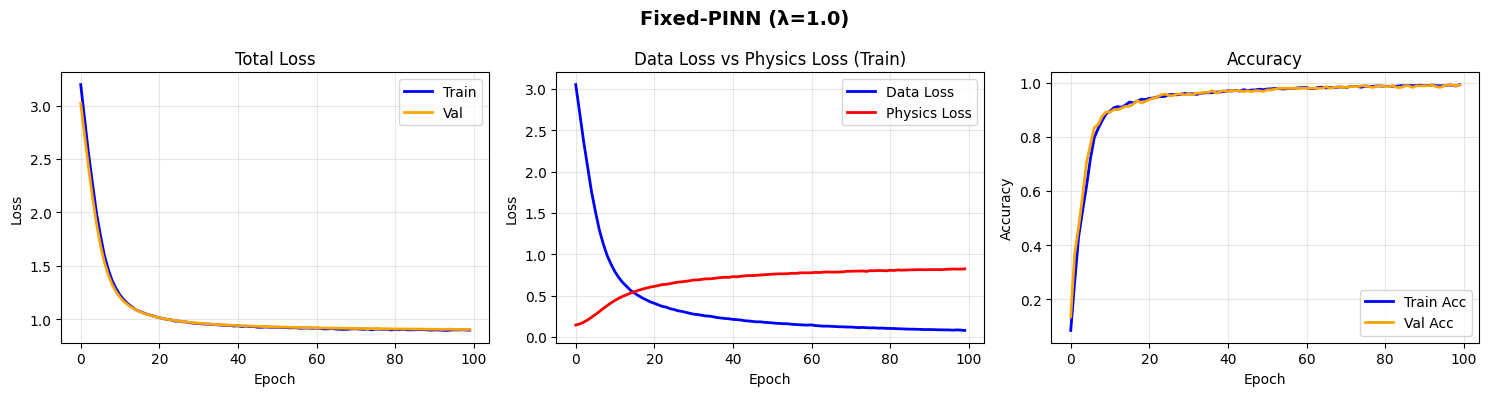

✅ Training curve disimpan


In [70]:
# ============================================================
# CELL 8: Plot Training Curve
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total Loss
axes[0].plot(history['train_total'], label='Train',
             color='blue', linewidth=2)
axes[0].plot(history['val_total'],   label='Val',
             color='orange', linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Data Loss vs Physics Loss
axes[1].plot(history['train_data'],    label='Data Loss',
             color='blue', linewidth=2)
axes[1].plot(history['train_physics'], label='Physics Loss',
             color='red', linewidth=2)
axes[1].set_title('Data Loss vs Physics Loss (Train)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracy
axes[2].plot(history['train_acc'], label='Train Acc',
             color='blue', linewidth=2)
axes[2].plot(history['val_acc'],   label='Val Acc',
             color='orange', linewidth=2)
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Fixed-PINN (λ={LAMBDA_PHYSICS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/02_fixed_pinn_training_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curve disimpan")

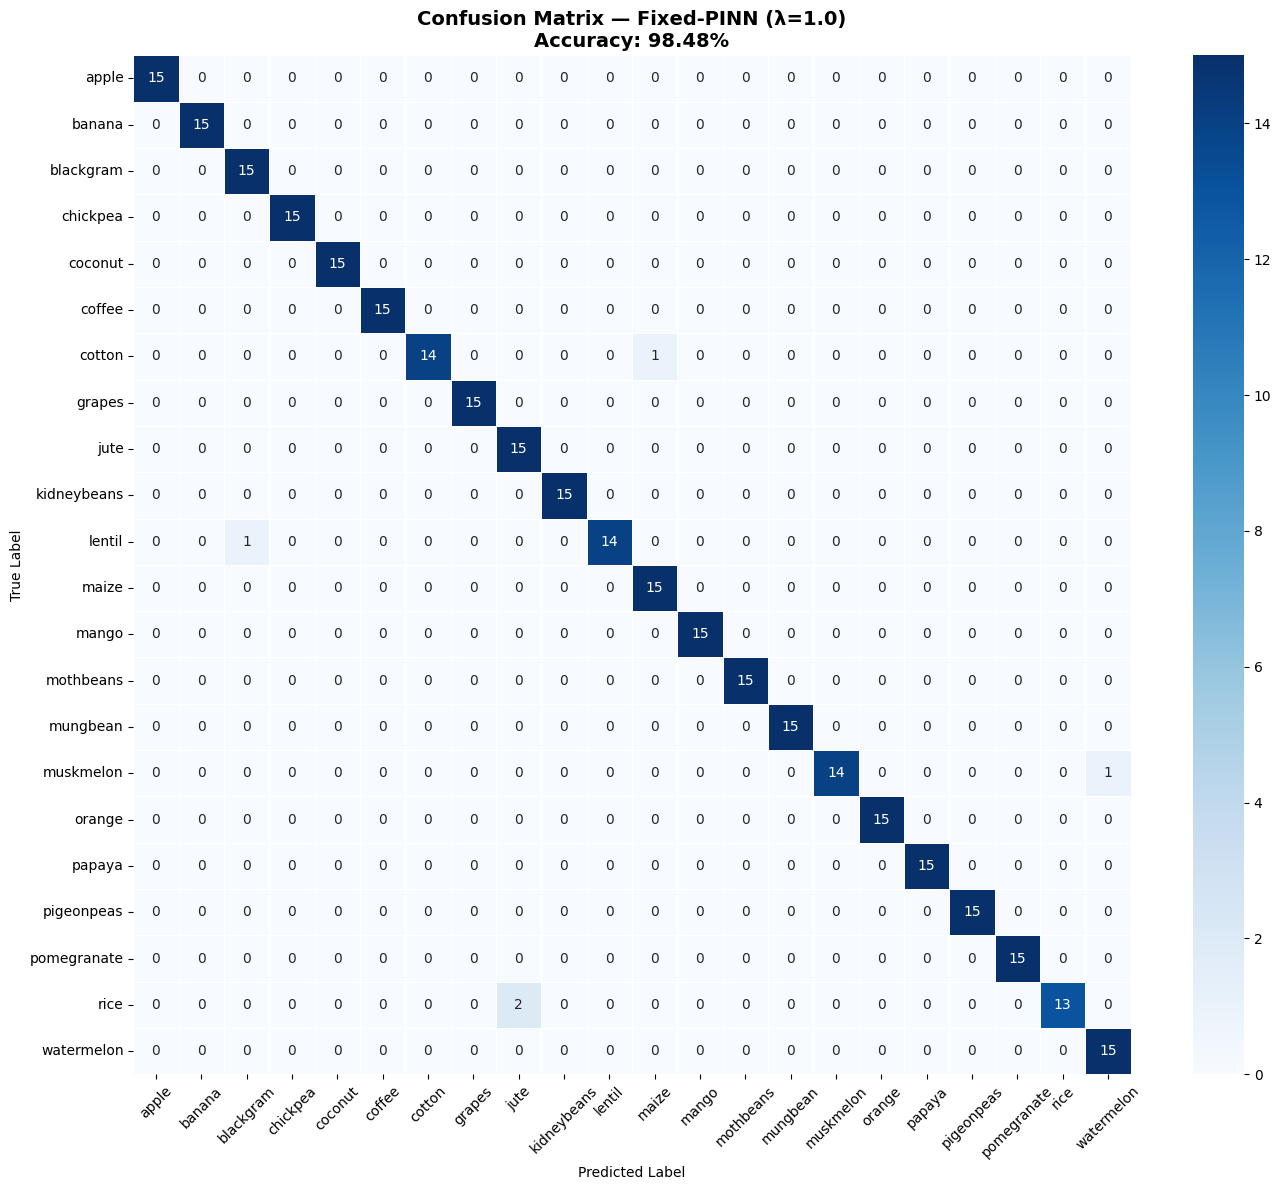

✅ Confusion matrix disimpan


In [71]:
# ============================================================
# CELL 9: Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_title(f'Confusion Matrix — Fixed-PINN (λ={LAMBDA_PHYSICS})\n'
             f'Accuracy: {acc*100:.2f}%',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('results/02_fixed_pinn_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")

In [72]:
# ============================================================
# CELL 10: Simpan Model dan Hasil
# ============================================================

model_pinn.save('models/fixed_pinn.keras')

results_pinn = {
    'history' : history,
    'metrics' : {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1_score' : f1,
    },
    'confusion_matrix': cm,
    'y_true'  : y_true,
    'y_pred'  : y_pred_l,
    'config'  : {
        'architecture'  : f'{INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}',
        'epochs'        : EPOCHS,
        'batch_size'    : BATCH_SIZE,
        'lr'            : LR,
        'lambda_physics': LAMBDA_PHYSICS,
    }
}

with open('session/results_fixed_pinn.pkl', 'wb') as f:
    pickle.dump(results_pinn, f)

print("✅ Model tersimpan  : models/fixed_pinn.keras")
print("✅ Hasil tersimpan  : session/results_fixed_pinn.pkl")
print(f"\nRingkasan:")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")

✅ Model tersimpan  : models/fixed_pinn.keras
✅ Hasil tersimpan  : session/results_fixed_pinn.pkl

Ringkasan:
  Accuracy  : 98.48%
  Precision : 98.61%
  Recall    : 98.48%
  F1-Score  : 98.48%
